In [ ]:
from sklearn.manifold import TSNE
from bokeh.io import output_notebook
from bokeh.plotting import figure, show
from bokeh.models import HoverTool, CustomJS, ColumnDataSource, Slider
from bokeh.layouts import column
from bokeh.palettes import all_palettes
output_notebook()

In [ ]:
pip install pdfminer.six

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 73.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from pdfminer.high_level import extract_pages
from pdfminer.layout import LTTextContainer

In [ ]:
dataset=[]
record=[]
name=""

In [ ]:
for i in range (1,21):
    print(i)
    text1=""
    name="pdf"+ str(i)+".pdf"
    for page_layout in extract_pages(name):
        for element in page_layout:
            if isinstance(element, LTTextContainer):
                #print(element.get_text())
                text1=text1+element.get_text()+"\n"
    record.append(text1)


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20


In [ ]:
import pandas as pd

# Define a dictionary containing data
data = {'Name': ["paper 1", "paper 2", " paper 3 ", "paper 4","paper 5","paper 6","paper 7","paper 8","paper 9","paper 10","paper 11","paper 12","paper 13","paper 14","paper 15","paper 16","paper 17","paper 18","paper 19","paper 20"] }
# Convert the dictionary into DataFrame
df = pd.DataFrame(data)

In [ ]:
df["content"] = record

In [ ]:
df.info()
df.to_csv('orthopdfcontent.csv')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Name     20 non-null     object
 1   content  20 non-null     object
dtypes: object(2)
memory usage: 448.0+ bytes


In [ ]:
import pandas as pd
df=pd.read_csv('orthopdfcontent.csv')

In [ ]:
import string
from nltk.corpus import stopwords
import re
from nltk.tokenize import RegexpTokenizer

In [ ]:

df['content'] = df['content'].apply(lambda x: re.sub("-\n",'',x))
df['content'] = df['content'].apply(lambda x: re.sub("\n",' ',x))

In [ ]:
#defining the function to remove punctuation

def remove_punctuation(text):
    text=text.replace("/n"," ")
    tokenizer = RegexpTokenizer(r"\w+")
    punctuationfree = tokenizer.tokenize(text)
    punctuationfree=" ".join([i for i in punctuationfree if i not in string.punctuation])
    return punctuationfree
#storing the puntuation free text
df['content']= df['content'].apply(lambda x:remove_punctuation(x))
df.head()

,Unnamed: 0,Name,content
0,0,paper 1,Variable Admittance Control for Human Robot Co...
1,1,paper 2,IEEE TRANSACTIONS ON NEURAL SYSTEMS AND REHABI...
2,2,paper 3,Safety and Accuracy Considerations in Developi...
3,3,paper 4,Archives of Orthopaedic and Trauma Surgery 202...
4,4,paper 5,J Orthop Sci 2003 8 442 448 Computer assisted ...


In [ ]:
df['content']= df['content'].apply(lambda x: x.lower())

In [ ]:
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

In [ ]:

lemmatizer = WordNetLemmatizer()
#A function which takes a sentence/corpus and gets its lemmatized version.
def lemmatizeSentence(sentence):
    token_words=word_tokenize(sentence)
#we need to tokenize the sentence or else lemmatizing will return the entire sentence as is.
    lemma_sentence=[]
    for word in token_words:
        lemma_sentence.append(lemmatizer.lemmatize(word))
        lemma_sentence.append(" ")
    return "".join(map(str,lemma_sentence))

In [ ]:
import nltk
nltk.download('stopwords')
STOPWORDS = set(stopwords.words('english'))
def remove_stopwords(text):
    return " ".join([word for word in str(text).split() if word not in STOPWORDS])

df["content"] = df["content"].apply(lambda text: remove_stopwords(text))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
nltk.download('punkt_tab')
nltk.download('wordnet')
df["content"] = df["content"].apply(lambda text: lemmatizeSentence(text))

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
df["content"] = df["content"].apply(lambda text: remove_stopwords(text))

In [ ]:
import re
df['content'] = df['content'].apply(lambda x: re.sub("\d",' ',x))
df['content'] = df['content'].apply(lambda x: re.sub("_",' ',x))
df['content'] = df['content'].apply(lambda x:' '.join( [w for w in x.split() if len(w)>2]))

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

In [ ]:

d=Counter(" ".join(df["content"]).split()).most_common(5)
f=dict(d)
f

{'system': 988, 'robot': 848, 'surgery': 781, 'robotic': 626, 'patient': 413}

<BarContainer object of 5 artists>

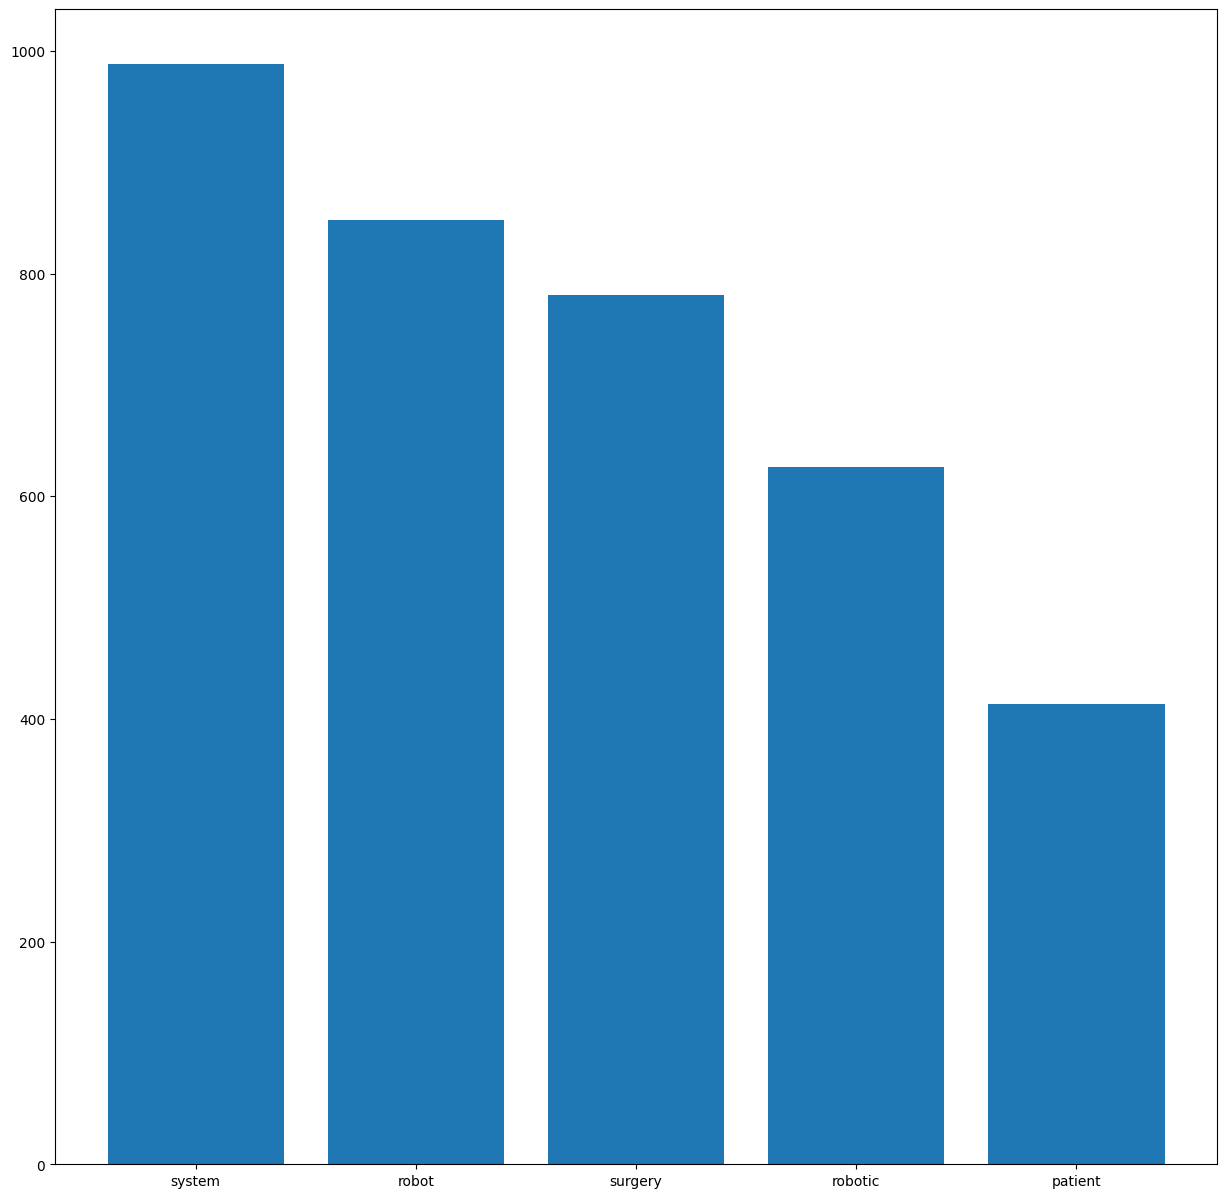

In [ ]:
names = list(f.keys())
values = list(f.values())
plt.figure(figsize=(15,15))
plt.bar(range(len(f)), values, tick_label=names)

In [ ]:
pip install keybert

In [ ]:
from keybert import KeyBERT

/usr/local/lib/python3.10/dist-packages/sentence_transformers/cross_encoder/CrossEncoder.py:13: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


In [ ]:
from sentence_transformers import SentenceTransformer
import torch

# Ensure model is loaded on GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Load the transformer model directly with GPU support
sentence_model = SentenceTransformer('all-mpnet-base-v2', device=device)
kw_model = KeyBERT(model=sentence_model)

Using device: cuda


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.6k [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
df['content_new']=df['content']

In [ ]:
for i in range(0,20):
    keywords = kw_model.extract_keywords(df['content'][i],keyphrase_ngram_range=(1, 3),highlight=False, top_n=70)
    keywords_list= list(dict(keywords).keys())
    s=""
    for kw in keywords_list:
        # print(kw)
        s=s+" "+kw
    df['content_new'][i]=s
    print(" ")
    print(i)
    print(" ")

<ipython-input-27-0918776da6d5>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['content_new'][i]=s


 
0
 


<ipython-input-27-0918776da6d5>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['content_new'][i]=s


 
1
 


<ipython-input-27-0918776da6d5>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['content_new'][i]=s


...

<ipython-input-27-0918776da6d5>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['content_new'][i]=s
<ipython-input-27-0918776da6d5>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['content_new'][i]=s


 
16
 
 
17
 


<ipython-input-27-0918776da6d5>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['content_new'][i]=s


 
18
 
 
19
 


<ipython-input-27-0918776da6d5>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['content_new'][i]=s


In [ ]:
d=Counter(" ".join(df["content_new"]).split()).most_common(5)
f=dict(d)
f

{'surgery': 381,
 'robot': 370,
 'robotic': 278,
 'orthopedic': 268,
 'robotics': 192}

<BarContainer object of 5 artists>

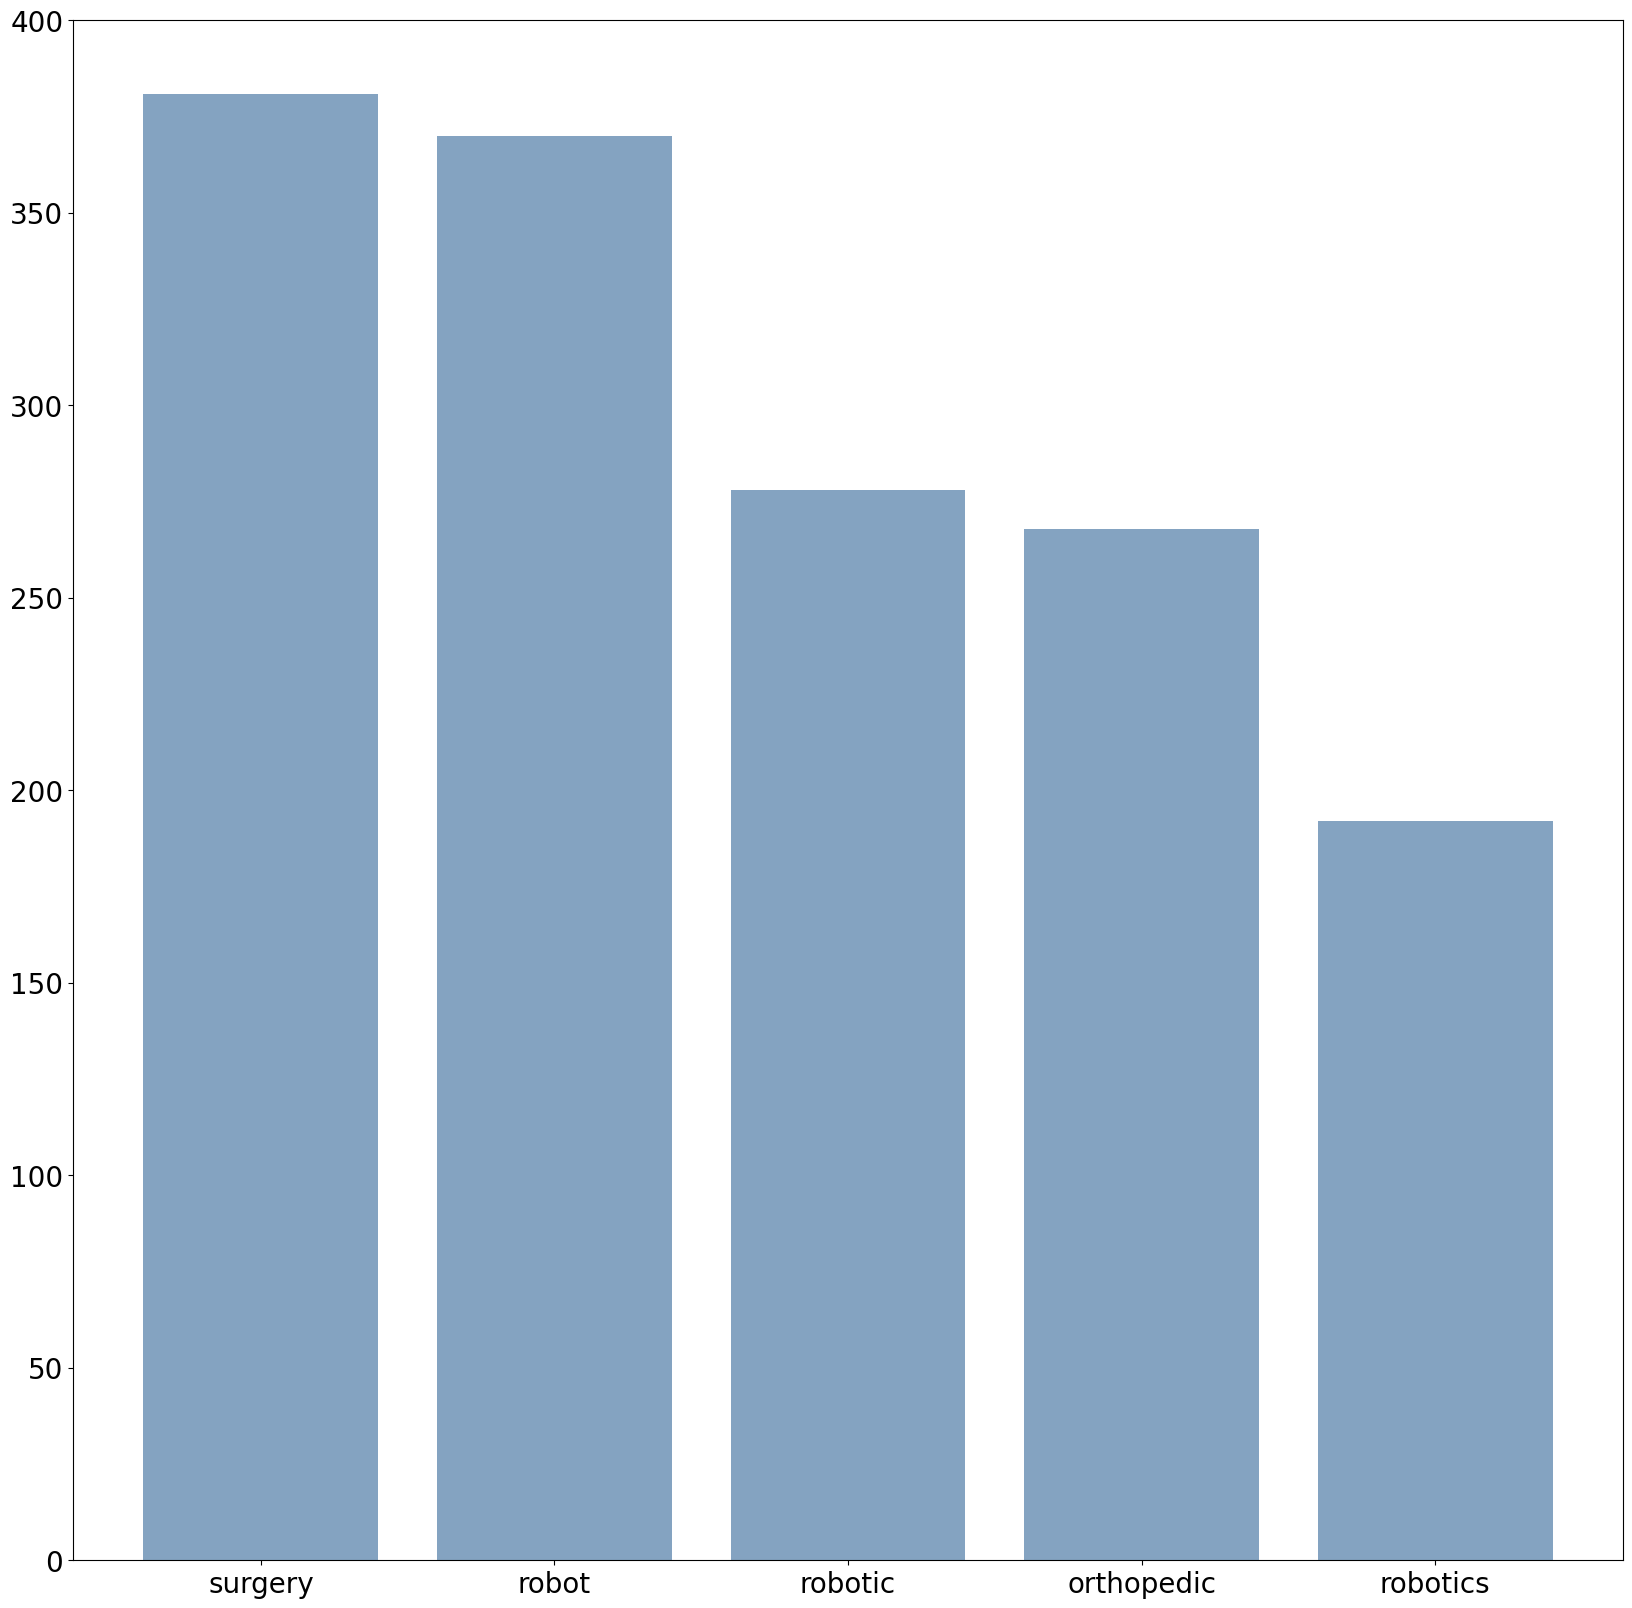

In [ ]:
names = list(f.keys())
values = list(f.values())
plt.figure(figsize=(20,20))
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
plt.bar(range(len(f)), values, tick_label=names,color=(0.2, 0.4, 0.6, 0.6))

In [ ]:
df

,Unnamed: 0,Name,content,content_new
0,0,paper 1,variable admittance control human robot collab...,orthopedic surgical robot robot assisted orth...
1,1,paper 2,ieee transaction neural system rehabilitation ...,robot aided rehabilitation patient robotic re...
2,2,paper 3,safety accuracy consideration developing small...,surgical robot knee robotics orthopaedic surg...
3,3,paper 4,archive orthopaedic trauma surgery http doi or...,surgical orthopedic robotic robotics orthopae...
4,4,paper 5,orthop sci computer assisted orthopedic surger...,computerassisted orthopedic surgery orthopedi...
5,5,paper 6,journal robotic surgery http doi org review re...,orthopedic surgery robotic robotics orthopedi...
6,6,paper 7,bmc musculoskeletal disorder http doi org rese...,robotics orthopedic surgery robotic orthopedi...
7,7,paper 8,brief history artificial intelligence robotic ...,robotic surgery orthopedics robotic surgeon e...
8,8,paper 9,proceeding ieee international conference robot...,conference robotics biomimetics robotics biom...
9,9,paper 10,development validity tissue biomechanics model...,biomechanical model surgical orthopedic surge...


In [ ]:
df.to_csv('bertortho.csv')

In [ ]:
import pandas as pd
df=pd.read_csv('bertortho.csv')

In [ ]:
x_train=df['content_new'].to_numpy()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer
tf_idf_vectorizer=TfidfVectorizer(min_df=0.07)

cv_vectorizer= CountVectorizer()

In [ ]:
tf_idf_arr= tf_idf_vectorizer.fit_transform(x_train)

# cv_arr=cv_vectorizer.fit_transform(x_train)

In [ ]:
import numpy as np

In [ ]:
tf_idf_arr

<20x178 sparse matrix of type '<class 'numpy.float64'>'
	with 689 stored elements in Compressed Sparse Row format>

In [ ]:
vocab_tf_idf = tf_idf_vectorizer.get_feature_names_out()

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation
lda_model= LatentDirichletAllocation(n_components=4, max_iter = 200, random_state=20)

X_topics= lda_model.fit_transform(tf_idf_arr)

topic_words=lda_model.components_

In [ ]:
# Log Likelyhood: Higher the better
print("Log Likelihood: ", lda_model.score(tf_idf_arr))

# Perplexity: Lower the better. Perplexity = exp(-1. * log-likelihood per word)
print("Perplexity: ", lda_model.perplexity(tf_idf_arr))

# See model parameters
print(lda_model.get_params())


Log Likelihood:  -471.4662308517012
Perplexity:  537.4310401054797
{'batch_size': 128, 'doc_topic_prior': None, 'evaluate_every': -1, 'learning_decay': 0.7, 'learning_method': 'batch', 'learning_offset': 10.0, 'max_doc_update_iter': 100, 'max_iter': 200, 'mean_change_tol': 0.001, 'n_components': 4, 'n_jobs': None, 'perp_tol': 0.1, 'random_state': 20, 'topic_word_prior': None, 'total_samples': 1000000.0, 'verbose': 0}


In [ ]:
import numpy as np

In [ ]:
topic_number =[]
word=[]

In [ ]:
n_top_words=5

# for i, topic_dist in enumerate(topic_words):

#     sorted_topic_dist = np.argsort(topic_dist)
#     topic_words = np.array(vocab_tf_idf)[sorted_topic_dist]

#     topic_words= topic_words[:-n_top_words:-1]
#     print("topic", str(i+1), topic_words)
#     topic_number.append("topic"+str(i+1))
#     word.append(topic_words)
#     print(" ")

In [ ]:
from gensim.models import CoherenceModel
from gensim.corpora import Dictionary

# Preprocessing: Tokenize and clean your text data (if not already done)
documents = [doc.split() for doc in df['content']]  # Replace with actual tokenized text data

# Create a Gensim dictionary and corpus
dictionary = Dictionary(documents)
corpus = [dictionary.doc2bow(doc) for doc in documents]

# Store topics' words and calculate coherence
topic_coherence_scores = []

# Iterate over each topic
for i, topic_dist in enumerate(topic_words):

    sorted_topic_dist = np.argsort(topic_dist)
    topic_words = np.array(vocab_tf_idf)[sorted_topic_dist]
    topic_words = topic_words[:-n_top_words:-1]
    print("Topic", str(i+1), topic_words)
    topic_number.append("Topic" + str(i+1))
    word.append(topic_words)

    # Calculate coherence score for each topic using gensim's CoherenceModel
    gensim_lda_topic = [dictionary[word_id] for word_id in sorted_topic_dist[-n_top_words:]]

    coherence_model = CoherenceModel(
        topics=[gensim_lda_topic],
        texts=documents,
        dictionary=dictionary,
        coherence='c_v'  # You can choose 'c_v', 'u_mass', or 'c_npmi'
    )

    coherence_score = coherence_model.get_coherence()
    topic_coherence_scores.append(coherence_score)
    print(f"Coherence score for Topic {i+1}: {coherence_score:.4f}")

    print(" ")

# Display all topics' coherence scores
print("\nTopic Coherence Scores:")
for idx, score in enumerate(topic_coherence_scores):
    print(f"Topic {idx+1}: {score:.4f}")


Topic 1 ['treatment' 'rehabilitation' 'experimental' 'introduction']
Coherence score for Topic 1: 0.2996
 
Topic 2 ['biomechanical' 'leg' 'model' 'modeling']
Coherence score for Topic 2: 0.2583
 
Topic 3 ['surgery' 'robot' 'robotic' 'orthopedic']
Coherence score for Topic 3: 0.3231
 
Topic 4 ['rehabilitation' 'treatment' 'experimental' 'motion']
Coherence score for Topic 4: 0.2874
 

Topic Coherence Scores:
Topic 1: 0.2996
Topic 2: 0.2583
Topic 3: 0.3231
Topic 4: 0.2874


In [ ]:
topic_df=pd.DataFrame(topic_number)
topic_df["topic words"]=word

In [ ]:
print(topic_df.to_string())

        0                                              topic words
0  Topic1  [treatment, rehabilitation, experimental, introduction]
1  Topic2                    [biomechanical, leg, model, modeling]
2  Topic3                    [surgery, robot, robotic, orthopedic]
3  Topic4        [rehabilitation, treatment, experimental, motion]


In [ ]:
doc_name=[]
doc_top=[]

In [ ]:
doc_topic=lda_model.transform(tf_idf_arr)

for n in range(doc_topic.shape[0]):

    topic_doc=doc_topic[n].argmax()

    print("document", n+1, " - - Topic: ", topic_doc+1)
    doc_name.append(n+1)
    doc_top.append(topic_doc+1)

document 1  - - Topic:  3
document 2  - - Topic:  4
document 3  - - Topic:  3
document 4  - - Topic:  3
document 5  - - Topic:  3
document 6  - - Topic:  3
document 7  - - Topic:  3
document 8  - - Topic:  3
document 9  - - Topic:  3
document 10  - - Topic:  2
document 11  - - Topic:  3
document 12  - - Topic:  3
document 13  - - Topic:  3
document 14  - - Topic:  3
document 15  - - Topic:  3
document 16  - - Topic:  3
document 17  - - Topic:  3
document 18  - - Topic:  3
document 19  - - Topic:  3
document 20  - - Topic:  2


In [ ]:
doc=pd.DataFrame(doc_name)
doc["topic"]=doc_top

In [ ]:
doc

,0,topic
0,1,3
1,2,4
2,3,3
3,4,3
4,5,3
5,6,3
6,7,3
7,8,3
8,9,3
9,10,2


<Axes: xlabel='topic', ylabel='count'>

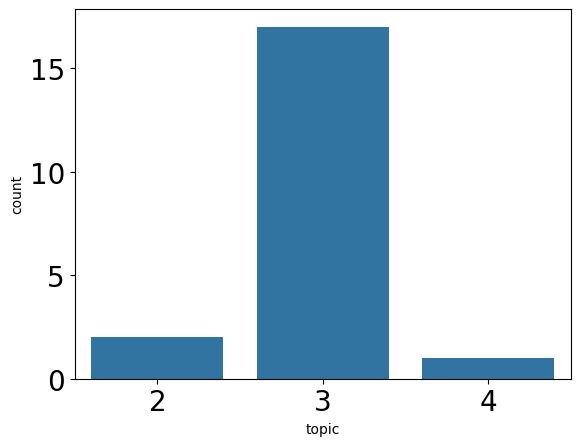

In [ ]:
import seaborn as sns
sns.countplot(x ='topic', data = doc)

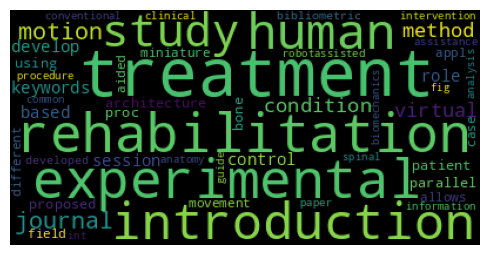

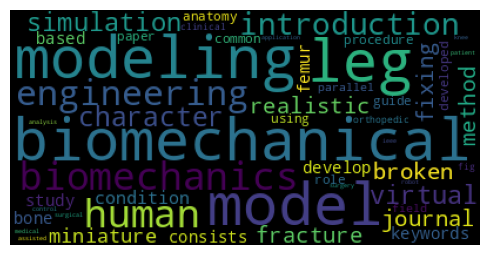

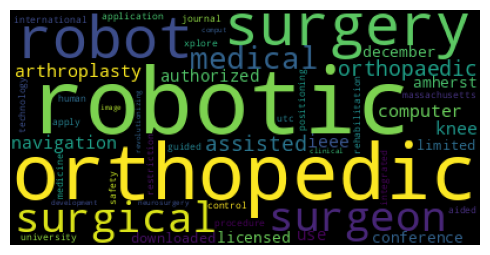

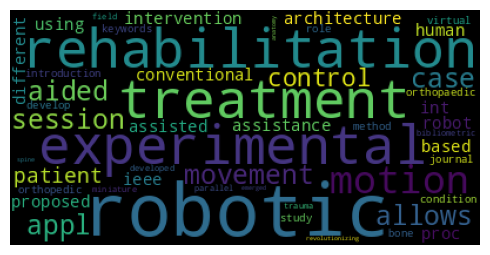

IndexError: index 4 is out of bounds for axis 0 with size 4

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
# Generate a word cloud image for given topic
def draw_word_cloud(index):
  imp_words_topic=""
  comp=lda_model.components_[index]
  vocab_comp = zip(vocab_tf_idf, comp)
  sorted_words = sorted(vocab_comp, key= lambda x:x[1], reverse=True)[:50]
  for word in sorted_words:
    imp_words_topic=imp_words_topic+" "+word[0]

  wordcloud = WordCloud().generate(imp_words_topic)
  plt.figure( figsize=(5,5))
  plt.imshow(wordcloud)
  plt.axis("off")
  plt.tight_layout()
  plt.show()
# topic 0
draw_word_cloud(0)
draw_word_cloud(1)
draw_word_cloud(2)
draw_word_cloud(3)